# Introduction

Welcome to the workshop!

Today you will practice the core loop of LLM-based text classification: run the model on a labeled validation set, inspect the performance metrics, adjust the prompt, and repeat. Getting comfortable with this loop is the main takeaway.

**Note on this workshop's setup:** We use a small local model that will perform poorly out of the box. The goal is to learn the workflow, not to achieve real usable results. See *Next steps* at the end of this notebook for how a real study would differ.

### Steps

1. **Define your construct.** A clear, literature-grounded definition makes labeling consistent and the model's task tractable. This has been done for you in today's workshop.

2. **Build a validation set.** Randomly sample examples from your data and label them by hand. Aim for at least 30–40 examples per class. This set is for prompt tuning only, not for final reporting. This has also been prepared for you today.

3. **Run and improve.** This is today's workshop. Run the classification on the validation set, check the metrics, adjust the prompt, and repeat.

4. **Evaluate on a held-out test set, then classify your full dataset.** These steps follow after the workshop. See *Next steps*.

# Load and install required packages


We will be using the python package: choicellm for our model calls to remove a lot of code specific to initializing a model and working with a smaller model as we do here.

However, know that this can just as well be done without this package but it makes the code a bit easier to follow

In [1]:
%pip install -qU choicellm krippendorff

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 6.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import krippendorff
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Clone the repository

Clone the workshop repository to get the required files

It contains a baseline prompt, a validation.csv, and a potential_examples.csv with some example transcripts you could use to improve your prompt

In [16]:
!git clone https://github.com/Kevinoost1/aps26_llm_ws.git

Cloning into 'aps26_llm_ws'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 45 (delta 24), reused 7 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 46.56 KiB | 744.00 KiB/s, done.
Resolving deltas: 100% (24/24), done.


In [19]:
%cd aps26_llm_ws
!git pull

[Errno 2] No such file or directory: 'aps26_llm_ws'
/content/aps26_llm_ws/aps26_llm_ws
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 68.19 KiB | 691.00 KiB/s, done.
From https://github.com/Kevinoost1/aps26_llm_ws
   6c0a40e..1c10921  main       -> origin/main
Updating 6c0a40e..1c10921
Fast-forward
 aps_ws.ipynb | 373 ++++++++++++++++++++++++++++++++++++++++++++++++++++-------
 1 file changed, 332 insertions(+), 41 deletions(-)


# Load in the validation DataFrame

The validation dataframe contains only a hand full of labeled examples. For an actual validation set it is recommended to use a lot more

The code just extracts the manual labels and exports the actual transcripts to a .txt, which is the format we are going to use for choicellm

In [20]:
df: pd.DataFrame = pd.read_csv('validation.csv')
y_true = df['manual_alienation']

with open('transcripts.txt', 'w', encoding='utf-8') as f:
    for t in zip(df['translation']):
        t_clean = str(t).replace('\n', ' ').replace('\r', ' ')
        f.write(t_clean + '\n')


# The Current Prompt

Running the code below, will print the starting prompt that we are going to try to improve today.

Note that this prompt has been divided into different parts for convenience:

1. The system prompt tells the model what 'role' it should take. A part of the default system prompt in the ChatGPT models is for example: 'you are a helpful assistant'. This system prompt is supplied during the entire classification process.

2. We have defined two categories for this workshop: 'Alienation' (i.e. us vs. them) rhetoric and 'Other', which is the rest category and will contain any transcripts that do not contain Alienation rhetoric.

3. Later on in this workshop you will encounter a third part of the prompt, namely examples. This turns the classification task from 'zero-shot' classification into 'few-shot' classification. This could massively improve performance if you supply the model with quality examples

4. The user prompt is made up of the categories, examples, and a new transcript for everything it needs to classify.

In [21]:
with open('prompt_full.json') as f:
  prompt = json.load(f)

sys_prompt = prompt['system_prompt']
cat_alienation = prompt['categories']['Alienation']
cat_other = prompt['categories']['Other']

print(f"""
    System Prompt: {sys_prompt}\n
    Definition of Alienation: {cat_alienation}\n
    Definition of Other: {cat_other}\n
    """
)


    System Prompt: # Main topic

You will see a few TikTok transcripts. Please rate them on whether you see a certain type of language.
follow the category definitions below.

{categories}

    Definition of Alienation: Talks of groups. Likely uses us vs. them rhetoric

    Definition of Other: The transcript does not contain rhetoric to do with Alienation

    


# Supervised Classification

Now, the actual classification step can begin. We are using a very small toy model for this workshop that does not perform very well out-of the box.

This is because for larger models you either need some very powerful computing resources (GPUs with enough VRAM) or you need to use an API, such as the one by OPENAI. If you are able to run a powerful model locally, just replace the value for the --model argument with the model link on HuggingFace or with a local folder. If you would like to use an API, you can similarly add the --model argument to the model you would like to use (e.g. 'gpt-4o') and add the second argument --openai

For demonstration purposes, we will continue to use the small model. The validation process stays the same

In [22]:
!choicellm transcripts.txt --model 'unsloth/Qwen2.5-7B-Instruct-bnb-4bit' --prompt 'prompt_full.json' > results.csv

args.seed=89946
NumExpr defaulting to 2 threads.
HTTP Request: HEAD https://huggingface.co/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/bdd404162d94997f390efbfa660eb3f21cbbc81d/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/bdd404162d94997f390efbfa660eb3f21cbbc81d/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/tree/main?recursive=true&expand=false

# Results

With our results retrieved, we can print and inspect if there is anything odd. Likely you will get almost exclusively 'Alienation' predictions due to the model not being very good.

In [23]:
results: pd.DataFrame = pd.read_csv('results.csv')
y_pred = results['pred']
y_prob = results['probs'].str.split(';').str[0].astype(float)

print(y_pred)

0     Alienation
1     Alienation
2     Alienation
3     Alienation
4     Alienation
5     Alienation
6          Other
7     Alienation
8     Alienation
9     Alienation
10    Alienation
11    Alienation
12    Alienation
13    Alienation
14    Alienation
15    Alienation
16    Alienation
17    Alienation
18    Alienation
19    Alienation
20    Alienation
21    Alienation
22    Alienation
23    Alienation
24    Alienation
25    Alienation
26    Alienation
27    Alienation
28    Alienation
29         Other
30    Alienation
31    Alienation
32    Alienation
33    Alienation
34    Alienation
Name: pred, dtype: object


# How does the prompt perform?

We use two main ways of assesing model performance:
- F1 score -> This metric describes a balance between precision and recall

A good F1 score depends on the task, but is generally between 0.7 and 0.9.


- Krippendorff's alpha -> Generally more conservative than F1 score. For validation, try to aim for at least 0.8 at a minimum. However, if you can get it above 0.9 that is even better. For the test set you can just report the metric that comes out. If both your validation set and test set are equally representative of your total data there's a good chance that optimization on the validation set to 0.8 or 0.9 will yield good results on the test set.

Both performance metrics do not care about class imbalance (unlike accuracy). Do keep in mind that with a larger class imbalance, you need a larger test set (it is also good to have a larger validation set in that case)


--------------------------------------------------------------------------------

There is one more metric that I think is very useful, namely the receiver operator characteristic curve (ROC) and its area under the curve (AUC). I highly recommend using this metric since it bases model performance not on the majority label as predicted by the model, but rather on the uncertainty from the model (class probabilities).

However, be careful with using this metric whenever you run a model through an API. It is very likely that the probabilities you get back from the API are not the actual logits from the model, which makes this metric useless.

In [24]:
def get_performance(y_true, y_pred, y_prob=None):
  report = classification_report(y_true, y_pred)

  le = LabelEncoder()
  le.fit(pd.concat([y_true, y_pred]))

  kripp_data = np.array([le.transform(y_true), le.transform(y_pred)])
  alpha = krippendorff.alpha(reliability_data=kripp_data, level_of_measurement='nominal')

  print(f'''
  Performance Report:\n\n
  Krippendorff Alpha: {alpha}\n
  Misc. metrics (incl. F1): {report}
  ''')

  if y_prob is not None:
    y_true_bin = (y_true == 'Alienation').astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_prob)
    auc = roc_auc_score(y_true_bin, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

  return report, alpha


  Performance Report:


  Krippendorff Alpha: -0.13994169096209919

  Misc. metrics (incl. F1):               precision    recall  f1-score   support

  Alienation       0.48      1.00      0.65        16
       Other       1.00      0.11      0.19        19

    accuracy                           0.51        35
   macro avg       0.74      0.55      0.42        35
weighted avg       0.76      0.51      0.40        35

  


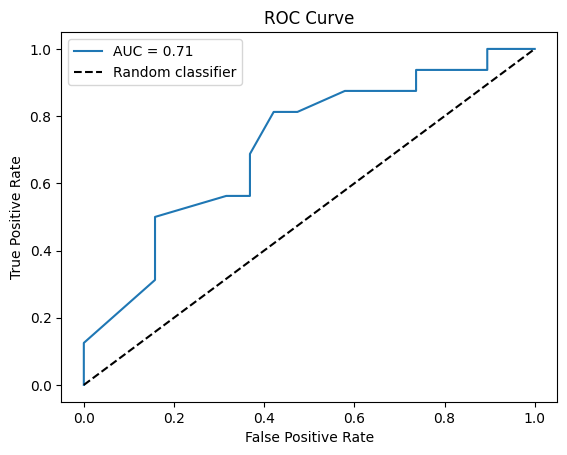

In [25]:
class_report, alpha = get_performance(y_true, y_pred, y_prob)

# Design your own


Now we can practice a bit with designing our own prompt. You can see the different parts of the prompt below and are allowed to edit them in whichever way you please.

A good way to do this is to edit small parts, then run the classification below, inspect the test scores, and repeat the process until you are satisfied.

Let's see how high you can get the validation scores, even if the model is currently not very good.

In [26]:
sys_prompt = f"""
# Main topic\n\n

You will see a few TikTok transcripts. Please rate them on whether you see a certain type of language.\n
follow the category definitions below.
"""

In [27]:
cat_alienation = f"""
Talks of groups. Likely uses us vs. them rhetoric
"""

In [28]:
cat_other = f"""
The transcript does not contain rhetoric to do with Alienation
"""

In [29]:
def create_new_prompt(sys_prompt, cat_alienation, cat_other, examples=prompt['examples']) -> None:
  new_prompt = prompt
  new_prompt['system_prompt'] = sys_prompt + '\n\n{categories}'
  new_prompt['categories']['Alienation'] = cat_alienation
  new_prompt['categories']['Other'] = cat_other
  new_prompt['examples'] = examples

  with open('new_prompt.json', 'w') as f:
    json.dump(new_prompt, f)

create_new_prompt(sys_prompt, cat_alienation, cat_other)

args.seed=72633
NumExpr defaulting to 2 threads.
HTTP Request: HEAD https://huggingface.co/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/bdd404162d94997f390efbfa660eb3f21cbbc81d/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/bdd404162d94997f390efbfa660eb3f21cbbc81d/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen2.5-7B-Instruct-bnb-4bit/tree/main?recursive=true&expand=false

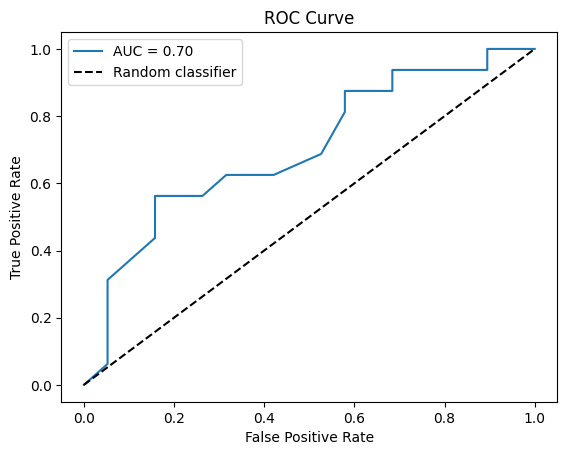

In [15]:
!choicellm transcripts.txt --model 'unsloth/Qwen2.5-7B-Instruct-bnb-4bit' --prompt 'new_prompt.json' > results.csv

results: pd.DataFrame = pd.read_csv('results.csv')
y_pred = results['pred']
y_prob = results['probs'].str.split(';').str[0].astype(float)

class_report, alpha = get_performance(y_true, y_pred, y_prob)

# Examples

One way to improve prompt performance drastically is by adding examples. This turns zero-shot classification into few-shot classification. Typically you inspect your validation set predictions, find where the model went wrong, and use those as examples. The best candidates are transcripts right on the border of two classes (grey area) or things the model consistently struggles with.

You can also supplement your validation set itself with hand-picked hard cases. Since the validation set is only for prompt tuning and not for final reporting, this is fine. It helps you stress-test your prompt against difficult examples. Keep in mind that a cherry-picked validation set will produce lower and less interpretable metric scores. Treat it as a qualitative check on edge cases rather than a performance benchmark.

Some potential transcripts you could use as examples can be found in the file `potential_examples.csv`. This can be downloaded from the GitHub:
https://github.com/Kevinoost1/aps26_llm_ws

In case you would like to add examples, add them in the dictionary format below. The `"item"` is the transcript and `"target_index"` is your label. This is zero-based: `target_index: 0` = 'Alienation', `target_index: 1` = 'Other'.

Just make sure that your examples do NOT appear in the validation set, and especially NOT the test set either. You can treat this part like a training set in classical machine learning / NLP tasks.

In [ ]:
examples = [
    {
      "item": "what on earth is going on in the house of Commons",
      "target_index": 1
    }
  ]

In [ ]:
create_new_prompt(sys_prompt, cat_alienation, cat_other, examples)

!choicellm transcripts.txt --model 'unsloth/Qwen2.5-7B-Instruct-bnb-4bit' --prompt 'new_prompt.json' > results.csv

results: pd.DataFrame = pd.read_csv('results.csv')
y_pred = results['pred']
y_prob = results['probs'].str.split(';').str[0].astype(float)

class_report, alpha = get_performance(y_true, y_pred, y_prob)

Continue improving your prompt by editing the cells above and re-running the classification. Each iteration should bring you closer to a well-performing prompt.

# Next steps

This workshop covered the validation and prompt optimization loop. Here is how the full workflow continues.

### Choosing a model

For this workshop we used a small local model to keep setup simple. In practice you have two main options:

- **Local model**: Stable and reproducible results, no data leaves your machine, fine-tuning is possible. Requires powerful hardware (GPU with enough VRAM) and more technical setup. Performance scales with model size.
- **API (e.g. GPT-4o, Claude)**: Frontier-level performance with minimal infrastructure. Downsides: predictions are less deterministic across runs, true model logits are not accessible (making AUC unreliable), and data is sent to an external server.

For privacy-sensitive data, a local model is strongly preferred.

### Evaluating on a test set

A test set is a *separate*, randomly sampled set from your data, labeled independently of the validation set. Key differences from the validation set:

- Sample randomly. Do not cherry-pick!
- Aim for at least 30–40 examples per class
- Run the classification once and report those numbers as-is
- Consider involving multiple human raters and resolving disagreements by majority vote

If using an API, run the classification multiple times and average the predictions to account for non-determinism.

### Classifying your full dataset

Once performance on the test set is confirmed, classify your full dataset and proceed with your research question. Note that it is possible to correct for classification errors in downstream analyses. Bootstrapping methods can account for model uncertainty when running regressions or t-tests on predicted labels.

# Helpful resources

**General overview of the methodology and good practices**

- Fang, Q., Bernardo, J. G., & van Kesteren, E. J. (2026). A Methodological Guide on Using Large Language Models for Text Annotation in the Social Sciences and Humanities with Python and R. arXiv preprint arXiv:2604.09638.doi.org/10.48550/arXiv.2604.09638

- Törnberg, P. (2024). Best practices for text annotation with large language models. arXiv preprint arXiv:2402.05129.

**Theoretical paper about LLMs and a small tutorial**

- Hussain, Z., Binz, M., Mata, R., & Wulff, D. U. (2024). A tutorial on open-source large language models for behavioral science. Behavior Research Methods, 56(8), 8214-8237. doi.org/10.3758/s13428-024-02455-8

**If you want to take it a step further - Interesting use of other NLP concepts for psychological research**

- Wulff, D. U., & Mata, R. (2025). Semantic embeddings reveal and address taxonomic incommensurability in psychological measurement. Nature Human Behaviour, 9(5), 944-954.